# Computational Physics with Python (Newman) — Chapter 4

Chapter 4 Solutions

## Exercise 4.1 — Factorials

Write a program to calculate and print the factorial of a number entered by the user.

If you wish, you can base your program on the user-defined function for factorial given in Section 2.6, but write your program so that it calculates the factorial using **integer variables**, not floating-point ones.

Use your program to calculate the factorial of $200$.

---

Now modify your program to use **floating-point variables** instead and again calculate the factorial of $200$.

What do you find? Explain.

In [22]:
def factorial_int(n):
    result = 1
    for i in range(n):
        result *= i+1
    return result

print("Python can represent any integer, no matter how big it is. However, the calc can be slower than a calc with a float.")
print("200!:", factorial_int(200))
print("----")

def factorial_float(n):
    result = 1.0 # Float
    for i in range(n):
        result *= i+1
    return result

print("200! overflows. Program doesn't crash, but uses an object named 'inf' to represent that overflow.")
print("200! (overflow):", factorial_float(200))

Python can represent any integer, no matter how big it is. However, the calc can be slower than a calc with a float.
200!: 788657867364790503552363213932185062295135977687173263294742533244359449963403342920304284011984623904177212138919638830257642790242637105061926624952829931113462857270763317237396988943922445621451664240254033291864131227428294853277524242407573903240321257405579568660226031904170324062351700858796178922222789623703897374720000000000000000000000000000000000000000000000000
----
200! overflows. Program doesn't crash, but uses an object named 'inf' to represent that overflow.
200! (overflow): inf


## Exercise 4.2 — Quadratic equations

Consider a quadratic equation $ax^2 + bx + c = 0$ that has real solutions.

a) Write a program that takes as input the three numbers, $a$, $b$, and $c$, and prints out the two solutions using the standard formula
$$
x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}.
$$
Use your program to compute the solutions of $0.001x^2 + 1000x + 0.001 = 0$.

b) There is another way to write the solutions to a quadratic equation. Multiplying top and bottom of the solution above by $-b \mp \sqrt{b^2 - 4ac}$, show that the solutions can also be written as

$$x = \frac{2c}{-b \mp \sqrt{b^2 - 4ac}}$$

Add further lines to your program to print these values in addition to the earlier ones and again use the program to solve $0.001x^2 + 1000x + 0.001 = 0$. What do you see? How do you explain it?

c) Using what you have learned, write a new program that calculates both roots of a quadratic equation accurately in all cases.

In [42]:
from math import sqrt
a = 0.001
b = 1000
c = 0.001
d = sqrt(b**2-4*a*c)
x1 = (-b+d)/(2*a) # Substraction error
x2 = (-b-d)/(2*a)

print("First way")
print(f"First solution: {x1}")
print(f"Second solution: {x2}")
print("----")

x1 = (2*c)/(-b-d)
x2 = (2*c)/(-b+d) # Substraction error
print("Second way")
print(f"First solution: {x1}")
print(f"Second solution: {x2}")

print(d)

print("---")
print("Third way")
x1 = (2*c)/(-b-d) # Avoid the substracion error.
x2 = (-b-d)/(2*a) # Avoid the substracion error.
print(f"First solution: {x1}")
print(f"Second solution: {x2}")

First way
First solution: -9.999894245993346e-07
Second solution: -999999.999999
----
Second way
First solution: -1.000000000001e-06
Second solution: -1000010.5755125057
999.999999998
---
Third way
First solution: -1.000000000001e-06
Second solution: -999999.999999


## Exercise 4.3 — Calculating derivatives

Suppose we have a function $f(x)$ and we want to calculate its derivative at a point $x$.  
We can do that with pencil and paper if we know the mathematical form of the function,  
or we can do it on the computer by making use of the definition of the derivative:

$$
\frac{df}{dx} = \lim_{\delta \to 0} \frac{f(x + \delta) - f(x)}{\delta}.
$$

On the computer we can’t actually take the limit as $\delta$ goes to zero, but we can get a reasonable approximation just by making $\delta$ small.

a) Write a program that defines a function $f(x)$ returning the value $x(x - 1)$, then calculates the derivative of the function at the point $x = 1$ using the formula above with $\delta = 10^{-2}$. Calculate the true value of the same derivative analytically and compare with the answer your program gives. The two will not agree perfectly. Why not?

b) Repeat the calculation for $\delta = 10^{-4}, 10^{-6}, 10^{-8}, 10^{-10}, 10^{-12},$ and $10^{-14}$. You should see that the accuracy of the calculation initially gets better as $\delta$ gets smaller, but then gets worse again. Why is this?

We will look at numerical derivatives in more detail in Section 5.10, where we will study techniques for dealing with these issues and maximizing the accuracy of our calculations.

First approximation: 1.010000000000001
Percentual error: 1.0000000000000897%


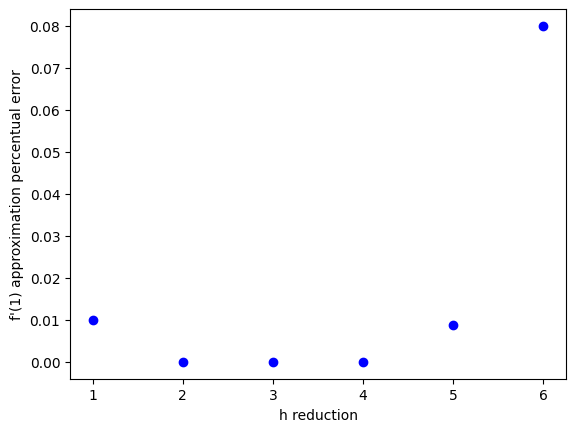

Exact number?: 1.00000000000001
Binary noise exposed by subtraction: 9.992007221626409e-15


In [75]:
import matplotlib.pyplot as plt

def f(x):
    return x * (x - 1)

real_value = 1

# Fixed the parenthesis structure here to follow: (f(x+h) - f(x)) / h
first_appr = (f(1 + 1e-2) - f(1)) / 1e-2
print(f"First approximation: {first_appr}")
print(f"Percentual error: {abs((real_value - first_appr) / real_value) * 100}%")

h_list = [1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-14]

# Fixed parenthesis structure inside the list comprehension
d_list = [(f(1 + h) - f(1)) / h for h in h_list]

plt.plot([i + 1 for i in range(len(h_list))], [abs((real_value - d) / real_value) * 100 for d in d_list], 'bo')
plt.xlabel("h reduction")
plt.ylabel("f'(1) approximation percentual error")
plt.show()

# The error increases significantly at h = 1e-14.
# When computing 1 + h, the value is extremely close to 1.
# Printing (1 + 1e-14) makes it look like an exact decimal representation:
print("Exact number?:", 1 + 1e-14)

# However, 1 + 1e-14 cannot be represented exactly in binary (base 2).
# This introduces rounding errors, leaving unrepresented bits at the end (floating-point noise).
# When we subtract f(1) from f(1+h), the large leading digits cancel out (catastrophic cancellation).
# The hardware normalizes the result by shifting the floating point to the right, exposing the hidden binary noise.
# This noise becomes dominant as h gets smaller, and the error is heavily amplified because we divide by a tiny quantity: h.
print("Binary noise exposed by subtraction:", (1 + 1e-14) - 1)
